# 03. Feature — 사이클 단위 피처 설계 및 정상 내부 오경보율 측정

## 배경
`01_eda.ipynb`·`02_eda_segment_patterns.ipynb`에서 확정된 것들:

- 분석 단위는 **세그먼트(=프레스 1사이클)**, 짧은 조각(n<10)은 통계가 불안정해 제외한다.
- 최강 피처 후보 세 가지가 나왔다 — `AI0_Vibration_rms`(진폭), `band_purity`(전류 사인
  순수도, AUC 0.9953), `env_cv`(진동 서브윈도우 RMS 변동계수, "균일성", AUC 0.9775).
  셋 다 서로 상관이 낮아(진폭↔균일성 normal 내부 corr 0.07~0.12) 결합할 가치가 있다.
- 이상은 간헐적이고(17개 중 3개는 정상과 구분 불가), 정상도 국지적으로 드리프트한다
  (01:00~01:17 V자 구간). → **고정 threshold 하나로는 부족**하다는 게 반복 확인됐다.

## 이 노트북에서 할 것
1. 검증된 세 피처(+보조 `AI0_Vibration_ac1`)로 피처 테이블을 만든다.
2. **정상 내부 오경보율을 측정한다** — 8번(다음 단계) 최우선 과제. normal을 시간순
   앞70%/뒤30%로 나눠, 앞으로 학습한 기준을 뒤(V자 구간 포함)에 적용했을 때 오경보가
   얼마나 나는지 직접 잰다. 이게 "이 데이터에서 오경보율의 실질적 하한"이다.
3. 피처를 하나의 결합 점수로 만들고, outlier 탐지율을 재확인한다.
4. 04(모델링)로 넘길 설계 결정을 정리한다.

## 0. 설정 및 로드

01·02와 동일한 정의를 그대로 가져온다(의도적으로 노트북마다 독립적으로 구성).

In [1]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# 현재 환경의 한글 폰트를 직접 등록한다 (기존 Matplotlib 캐시와 무관하게 적용).
for _font_path in [Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
                   Path("/mnt/c/Windows/Fonts/malgun.ttf")]:
    if _font_path.exists():
        font_manager.fontManager.addfont(str(_font_path))

_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]:
    if _f in _avail:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8})

DATA_DIR = Path(os.environ.get("KAMP_DATA_DIR", "/mnt/d/data/kamp_ai/press_anomaly_dataset"))
FS, GAP_THR = 10.0, 0.15
MIN_N    = 10          # 01·02와 동일: 1초 미만 세그먼트는 제외
COLOR    = {"normal": "#1f77b4", "outlier": "#d62728"}

normal  = pd.read_csv(DATA_DIR / "press_data_normal.csv", index_col=0, parse_dates=["TimeStamp"])
outlier = pd.read_csv(DATA_DIR / "outlier_data.csv",      index_col=0, parse_dates=["TimeStamp"])
DFS = {"normal": normal, "outlier": outlier}

def make_segments(df):
    d = df["TimeStamp"].diff().dt.total_seconds()
    out = df.copy(); out["seg_id"] = (d > GAP_THR).cumsum().values
    return out

SEG = {k: make_segments(df) for k, df in DFS.items()}
print({k: len(v.seg_id.unique()) for k, v in SEG.items()}, "개 세그먼트")

{'normal': 599, 'outlier': 21} 개 세그먼트


## 1. 피처 함수 — 02에서 검증된 세 가지 그대로

`band_purity`는 normal에서 실제 관측되는 전류 주기대(0.9~2.2초)로 탐색을 제한한 버전이다
(원 `sine_r2`는 짧은 램프를 사인으로 오인하는 문제가 있어 02에서 폐기했다).
`envelope_cv`는 1초(10샘플) 서브윈도우 RMS의 변동계수로, n≥20일 때만 신뢰할 수 있다
(02에서 확인: n<20이면 서브윈도우가 1개 이하라 계산 자체가 불가능하거나 불안정).

In [2]:
def band_purity(x, fs=FS, fmin=1/2.2, fmax=1/0.9):
    n = len(x); x = np.asarray(x, float) - np.mean(x)
    F = np.fft.rfft(x); freqs = np.fft.rfftfreq(n, d=1/fs)
    P = np.abs(F) ** 2
    band = (freqs >= fmin) & (freqs <= fmax)
    tot = P[1:].sum()
    return P[band].max() / tot if tot > 0 and band.any() else 0.0

def envelope_cv(x, win=10):
    # 1초(10샘플) 서브윈도우별 RMS의 변동계수. 서브윈도우가 2개 미만(n<20)이면 NaN
    x = np.asarray(x, float)
    n = len(x) // win
    if n < 2: return np.nan
    chunks = x[:n*win].reshape(n, win)
    sub_rms = np.sqrt((chunks ** 2).mean(axis=1))
    m = sub_rms.mean()
    return sub_rms.std() / m if m > 0 else np.nan

def build_features(sdf, label):
    rows = []
    for sid, g in sdf.groupby("seg_id"):
        if len(g) < MIN_N: continue
        x0, x2 = g["AI0_Vibration"].values, g["AI2_Current"].values
        rows.append({
            "label": label, "seg_id": sid, "n": len(g), "t_start": g.TimeStamp.iloc[0],
            "ai0_rms": float(np.sqrt((x0 ** 2).mean())),
            "ai0_ac1": float(pd.Series(x0).autocorr(1)) if len(g) > 3 else np.nan,
            "purity":  band_purity(x2),
            "env_cv":  envelope_cv(x0),
        })
    return pd.DataFrame(rows)

F  = pd.concat([build_features(SEG[k], k) for k in DFS], ignore_index=True)
Fn = F[F.label == "normal"].sort_values("t_start").reset_index(drop=True)
Fo = F[F.label == "outlier"].sort_values("t_start").reset_index(drop=True)

print(f"normal {len(Fn)}개 (env_cv 결측 {Fn.env_cv.isna().sum()}개)")
print(f"outlier {len(Fo)}개 (env_cv 결측 {Fo.env_cv.isna().sum()}개: "
      f"seg {Fo.loc[Fo.env_cv.isna(),'seg_id'].tolist()})")
display(Fn[["ai0_rms","ai0_ac1","purity","env_cv"]].describe().round(4))

normal 530개 (env_cv 결측 78개)
outlier 17개 (env_cv 결측 4개: seg [4, 14, 19, 20])


,ai0_rms,ai0_ac1,purity,env_cv
count,530.0000,530.0000,530.0000,452.0000
mean,0.0676,-0.0238,0.8590,0.1735
std,0.0216,0.3056,0.1979,0.0876
min,0.0229,-0.6654,0.1496,0.0004
25%,0.0489,-0.2924,0.7911,0.1067
50%,0.0696,-0.0315,0.9720,0.1709
75%,0.0838,0.2133,0.9954,0.2353
max,0.1478,0.6982,0.9996,0.5305


## 2. 정상 내부 오경보율 측정 (최우선 과제)

의도: normal을 시간순으로 앞 70% / 뒤 30%로 쪼갠다. **앞부분만으로 기준(임계값)을 정하고,
뒷부분(정상인데 모델은 본 적 없는 데이터)에 그대로 적용**했을 때 오경보가 몇 개나 나는지
잰다. 뒤 30%에는 02에서 찾은 V자 드리프트 구간(01:00~01:17)이 통째로 들어있어서, "정상의
자연스러운 운전조건 변화 때문에 오경보가 느는가"를 가장 가혹한 조건에서 시험하는 셈이다.

In [3]:
split = Fn.t_start.quantile(0.70)
train, test = Fn[Fn.t_start < split].copy(), Fn[Fn.t_start >= split].copy()
dip_in_test = (test.t_start >= pd.Timestamp("2022-07-12 01:00:00")).sum()

print(f"train(앞 70%) {len(train)}개  [{train.t_start.min()} ~ {train.t_start.max()}]")
print(f"test (뒤 30%) {len(test)}개  [{test.t_start.min()} ~ {test.t_start.max()}]")
print(f"  -> test 안에 V자 딥 구간(01:00~) 세그먼트 {dip_in_test}개 포함"
      f" ({dip_in_test/len(test)*100:.0f}%) — 가장 가혹한 조건")

train(앞 70%) 371개  [2022-07-12 00:00:00.019000 ~ 2022-07-12 00:53:27.876000]
test (뒤 30%) 159개  [2022-07-12 00:53:35.908000 ~ 2022-07-12 01:16:51.528000]
  -> test 안에 V자 딥 구간(01:00~) 세그먼트 115개 포함 (72%) — 가장 가혹한 조건


In [4]:
FEATS = {"ai0_rms": ">", "purity": "<", "env_cv": ">", "ai0_ac1": ">"}

rows = []
for f, direction in FEATS.items():
    thr = train[f].max() if direction == ">" else train[f].min()
    fa  = (test[f] > thr).sum() if direction == ">" else (test[f] < thr).sum()
    valid = test[f].notna().sum()
    rows.append({"피처": f, "방향": direction, "train 임계(FP=0)": round(thr, 4),
                 "test 오경보": f"{fa}/{valid}", "오경보율": round(fa/valid*100, 2)})
display(pd.DataFrame(rows).set_index("피처"))

,방향,train 임계(FP=0),test 오경보,오경보율
피처,,,,
ai0_rms,>,0.1478,0/159,0.00
purity,<,0.1578,1/159,0.63
env_cv,>,0.5305,0/134,0.00
ai0_ac1,>,0.6982,0/159,0.00


**결과:** 개별 피처 전부 **오경보율 0~0.6%**다. V자 딥 구간(진폭이 40% 가까이 줄어드는
구간)을 통째로 포함한 test셋인데도 거의 오경보가 나지 않는다 — 이유는 딥 구간이 신호를
"더 작고 조용하게" 만들 뿐이라, `ai0_rms`·`env_cv`처럼 "크면 이상"으로 보는 피처 입장에서는
오히려 더 안전한 쪽으로 움직이기 때문이다(02에서 확인한 대로 딥 구간도 같은 파형·같은
주기가 유지되고 진폭만 준다 — 파형이 깨지는 게 아니다). **01_eda·02에서 우려했던
"정상 드리프트로 인한 오경보"는 적어도 이번 데이터·이 피처들에서는 기우였다.**

## 3. 결합 점수 설계

의도: 세 피처(진폭·전류순수도·균일성)를 하나의 이상도 점수로 합친다. 서로 스케일이 달라
train 기준으로 z-score화한 뒤 평균한다. `env_cv`가 결측인 짧은 세그먼트(n<20)는 있는
피처만으로 평균 내도록 `nanmean`을 쓴다 — 세그먼트가 짧다는 이유로 통째로 버리지 않는다.

In [5]:
def z(s, ref):
    return (s - ref.mean()) / ref.std()

def combo_score(df, ref):
    parts = [z(df.ai0_rms, ref.ai0_rms), -z(df.purity, ref.purity), z(df.env_cv, ref.env_cv)]
    M = np.vstack([p.values for p in parts])
    return np.nanmean(M, axis=0)

train["score"] = combo_score(train, train)
test["score"]  = combo_score(test,  train)
Fo["score"]    = combo_score(Fo,    train)
Fn["score"]    = combo_score(Fn,    train)

thr_combo = train.score.max()
fa_combo  = (test.score > thr_combo).sum()
print(f"결합점수 train 임계(FP=0) = {thr_combo:.3f}")
print(f"test 오경보: {fa_combo}/{len(test)} ({fa_combo/len(test)*100:.1f}%)")

det = Fo.score > thr_combo
print(f"\noutlier 탐지: {det.sum()}/{len(Fo)}  미탐지 seg: {Fo.loc[~det,'seg_id'].tolist()}")
display(Fo[["seg_id","n","t_start","ai0_rms","purity","env_cv","score"]].round(4))

결합점수 train 임계(FP=0) = 1.876
test 오경보: 0/159 (0.0%)

outlier 탐지: 14/17  미탐지 seg: [3, 19, 20]


,seg_id,n,t_start,ai0_rms,purity,env_cv,score
0,1,50,2022-07-17 10:51:16.724,0.3913,0.0692,0.6447,8.7183
1,2,47,2022-07-17 10:51:23.615,0.5152,0.0563,0.4911,10.3693
2,3,31,2022-07-17 10:51:31.734,0.0458,0.0671,0.3715,1.5753
3,4,18,2022-07-17 10:51:39.999,0.6992,0.3245,NaN,18.0608
4,6,50,2022-07-17 10:51:56.684,0.5597,0.1373,0.7099,11.8340
5,7,40,2022-07-17 10:52:04.407,0.3374,0.1749,0.7681,8.0421
6,8,25,2022-07-17 10:52:12.567,0.3314,0.2021,0.6555,7.4700
7,11,50,2022-07-17 10:52:38.172,0.3561,0.0066,0.9496,9.3338
8,12,42,2022-07-17 10:52:45.655,0.4663,0.0350,0.7736,10.5868
9,13,28,2022-07-17 10:52:53.769,0.8385,0.0767,0.2511,15.1813


**결과:** 결합 점수도 **test 오경보 0%**를 유지하면서, outlier **17개 중 14개**를 잡는다.
미탐지는 여전히 **seg 3·19·20** — 01_eda(임계값 미탐지)·02(tier 분류) 두 가지 독립적
방법에서 이미 나온 것과 **정확히 같은 세 개**다. 세 번째 독립적 접근(결합 점수)에서도
동일하게 재현된다는 건, 이 셋이 우연이 아니라 **이 신호로는 원리적으로 못 잡는
하한**이라는 뜻이다(이 셋은 진폭·전류·균일성 전부 정상 범위 안에 있다 — 01_eda 5번
교락 문제와 관련해 "정말 이상인지"조차 재고할 여지가 있다).

### 3-1. 미탐지 세그먼트의 피처 시계열

의도: 미탐지 seg 3·19·20이 주변 이상 세그먼트와 어떻게 다른지, outlier 전체의 시간 흐름에서
확인한다. 세 결합 피처(`ai0_rms`, `purity`, `env_cv`)와 보조 `ai0_ac1`, 결합 점수를
같은 시간축에 놓고 **미탐지는 주황색**, 정상 학습 구간의 최솟값~최댓값은 회색 띠로 표시한다.
점선은 개별 피처의 정상 학습 극값 기준이며, 실제 미탐지 여부는 마지막 패널의 결합 점수로 정한다.

각 점은 세그먼트 전체에서 계산한 값이며 x축은 세그먼트 시작 시각이다.
세그먼트 사이 선은 흐름을 보기 위한 연결선으로, gap 구간의 신호를 보간한 것은 아니다.
`env_cv`가 없는 짧은 세그먼트는 값을 채우지 않고 축 아래에 결측으로 표시한다.


,seg_id,n,t_start,ai0_rms,purity,env_cv,ai0_ac1,score
2,3,31,2022-07-17 10:51:31.734,0.0458,0.0671,0.3715,0.0614,1.5753
15,19,10,2022-07-17 10:53:42.668,0.0321,0.3999,NaN,0.5906,0.1083
16,20,15,2022-07-17 10:53:52.140,0.0433,0.0066,NaN,0.3747,1.4056


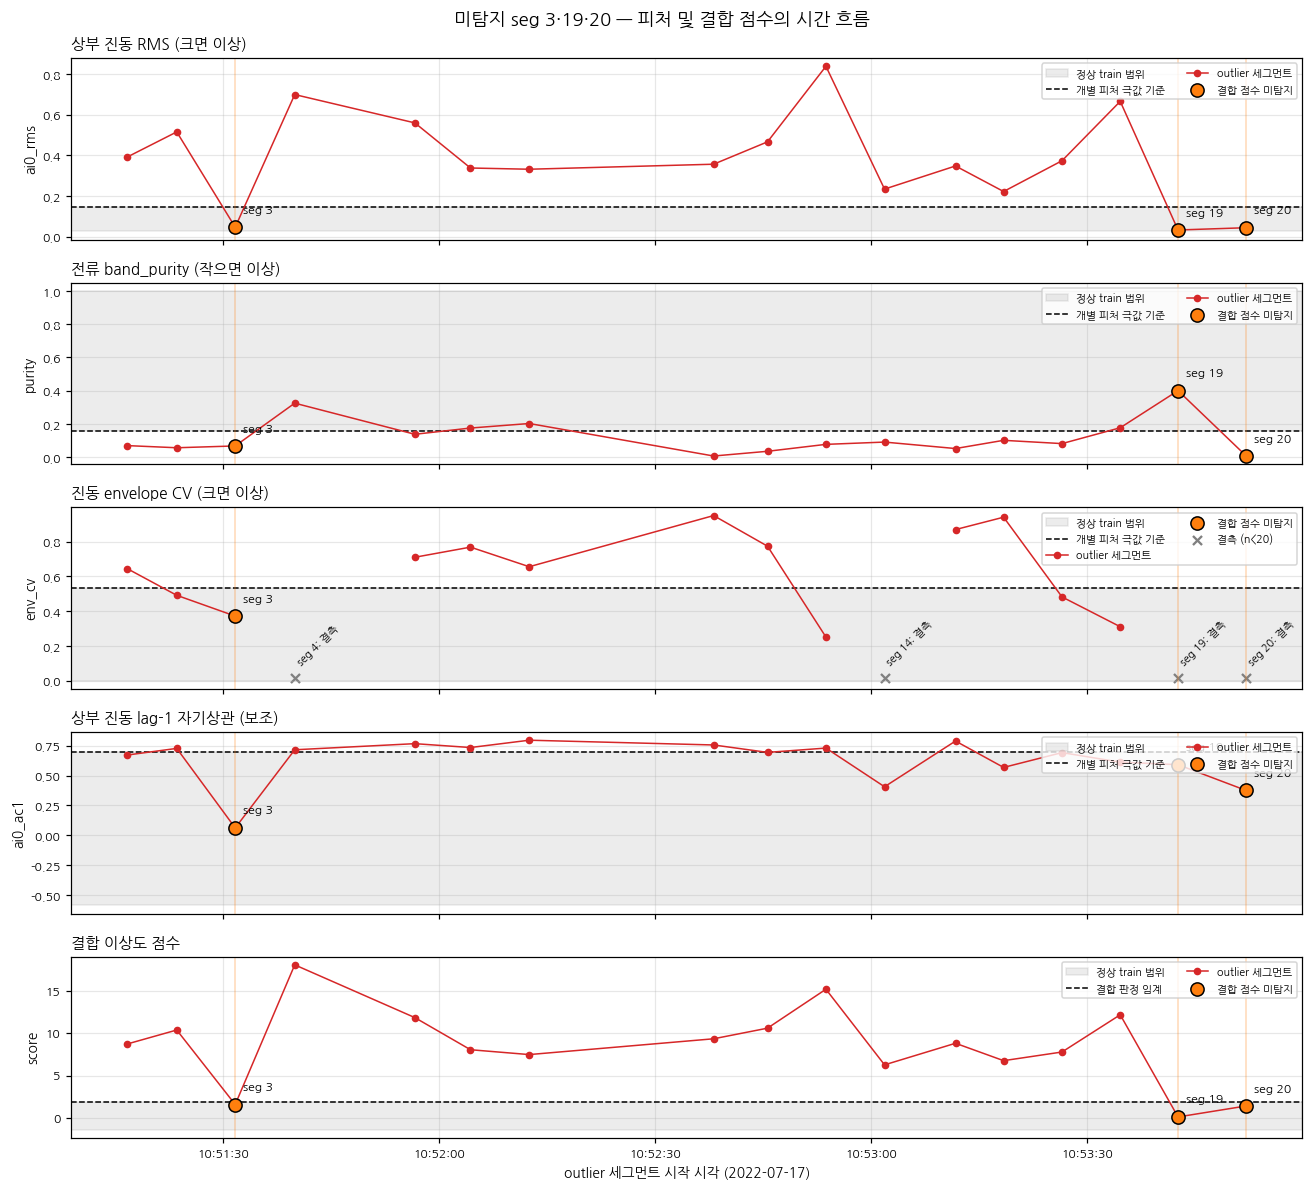

In [6]:
import matplotlib.dates as mdates

miss_mask = Fo["score"] <= thr_combo
miss_features = Fo.loc[miss_mask, ["seg_id", "n", "t_start", "ai0_rms", "purity",
                                   "env_cv", "ai0_ac1", "score"]]
display(miss_features.round(4))

panels = [("ai0_rms", "상부 진동 RMS (크면 이상)", ">"),
          ("purity", "전류 band_purity (작으면 이상)", "<"),
          ("env_cv", "진동 envelope CV (크면 이상)", ">"),
          ("ai0_ac1", "상부 진동 lag-1 자기상관 (보조)", ">"),
          ("score", "결합 이상도 점수", ">")]
fig, axes = plt.subplots(len(panels), 1, figsize=(12, 11), sharex=True)
for ax, (feat, title, direction) in zip(axes, panels):
    ref = train[feat].dropna()
    threshold = thr_combo if feat == "score" else (ref.max() if direction == ">" else ref.min())
    ax.axhspan(ref.min(), ref.max(), color="gray", alpha=.15, label="정상 train 범위")
    ax.axhline(threshold, color="black", ls="--", lw=1,
               label="결합 판정 임계" if feat == "score" else "개별 피처 극값 기준")
    ax.plot(Fo.t_start, Fo[feat], "o-", color=COLOR["outlier"], ms=4, lw=1,
            label="outlier 세그먼트")
    valid_miss = miss_mask & Fo[feat].notna()
    ax.scatter(Fo.loc[valid_miss, "t_start"], Fo.loc[valid_miss, feat],
               s=75, color="#ff7f0e", edgecolor="black", zorder=5, label="결합 점수 미탐지")
    for row in Fo.loc[miss_mask].itertuples():
        ax.axvline(row.t_start, color="#ff7f0e", alpha=.3, lw=1)
        value = getattr(row, feat)
        if pd.notna(value):
            ax.annotate(f"seg {row.seg_id}", (row.t_start, value), xytext=(5, 9),
                        textcoords="offset points", fontsize=8)
    missing = Fo[feat].isna()
    if missing.any():
        ax.scatter(Fo.loc[missing, "t_start"], np.full(missing.sum(), .06),
                   transform=ax.get_xaxis_transform(), marker="x", color="gray", s=35,
                   label="결측 (n<20)")
        for row in Fo.loc[missing].itertuples():
            ax.text(row.t_start, .13, f"seg {row.seg_id}: 결측", rotation=45, fontsize=7,
                    transform=ax.get_xaxis_transform(), ha="left")
    ax.set_title(title, loc="left")
    ax.set_ylabel(feat)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
axes[-1].set_xlabel("outlier 세그먼트 시작 시각 (2022-07-17)")
fig.suptitle("미탐지 seg 3·19·20 — 피처 및 결합 점수의 시간 흐름", fontsize=12)
plt.tight_layout(); plt.show()


**읽는 법:** seg 3은 낮은 전류 순수도와 높은 `env_cv`가 보여도 진동 RMS가 낮아,
평균한 결합 점수는 임계 아래에 남는다. seg 19·20은 `n=10·15`로 짧아 `env_cv`가 결측이고,
진동 RMS와 전류 순수도 두 피처만으로 점수를 낸다. 특히 seg 20도 전류 순수도는 낮지만
결합 점수는 임계를 넘지 못한다.

따라서 이 그림은 **현재 결합 방식과 임계에서 미탐지된 이유**를 살펴보는 자료다.
세 피처가 모두 정상처럼 보이거나 다른 판정 방식으로도 탐지가 불가능하다는 뜻은 아니다.


### 3-2. 미탐지 seg 3·19·20 — 원시 파형

의도: 각 미탐지 세그먼트의 상부 진동·하부 진동·전류 원시 파형을 별도 그림으로 확인한다.
x축은 실제 timestamp 기준의 세그먼트 내 경과시간이며, 점은 관측 샘플이다.
같은 채널은 세 그림에서 y축 범위를 통일한다.

상부 진동의 ±RMS 임계선은 **진폭 참고선**이다. RMS는 세그먼트 전체 통계이므로,
개별 샘플이 선을 넘었다고 이상으로 판정하지 않는다. purity·env CV는 원시값과 단위가 달라
수치로 비교한다. 최종 판정 기준은 결합 점수가 정상 학습 최대 점수를 초과하는지다.


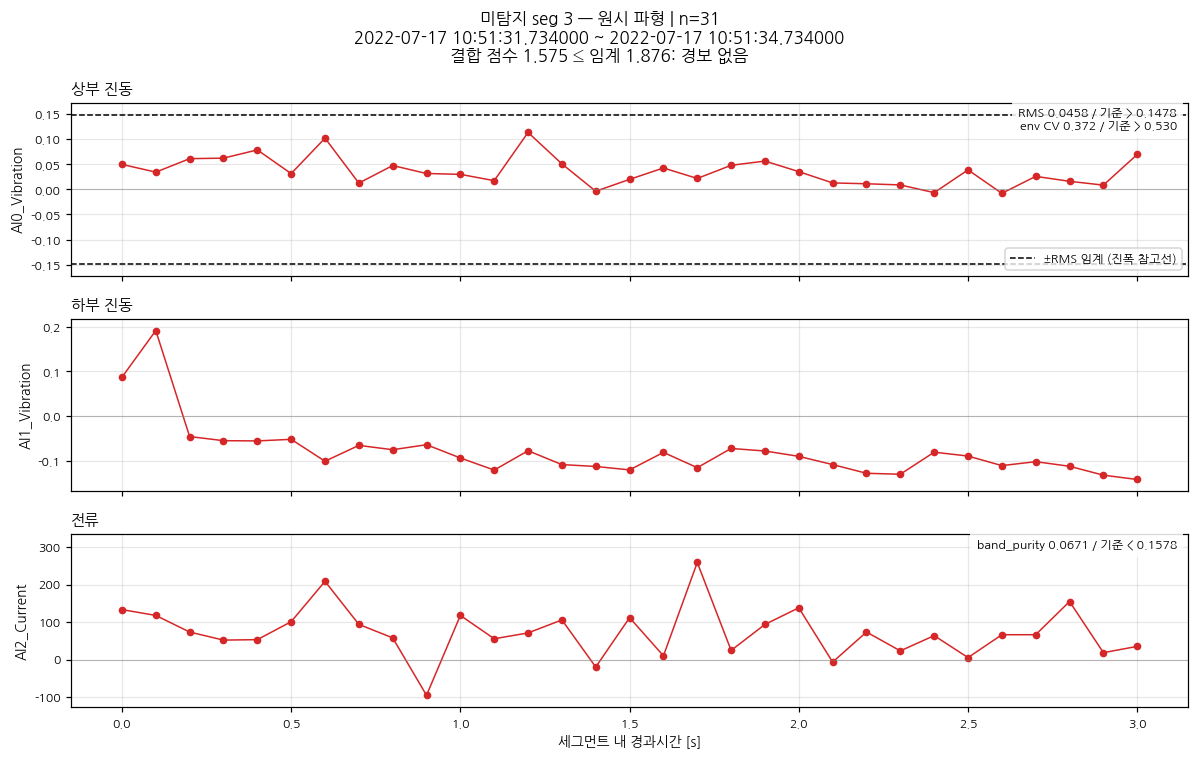

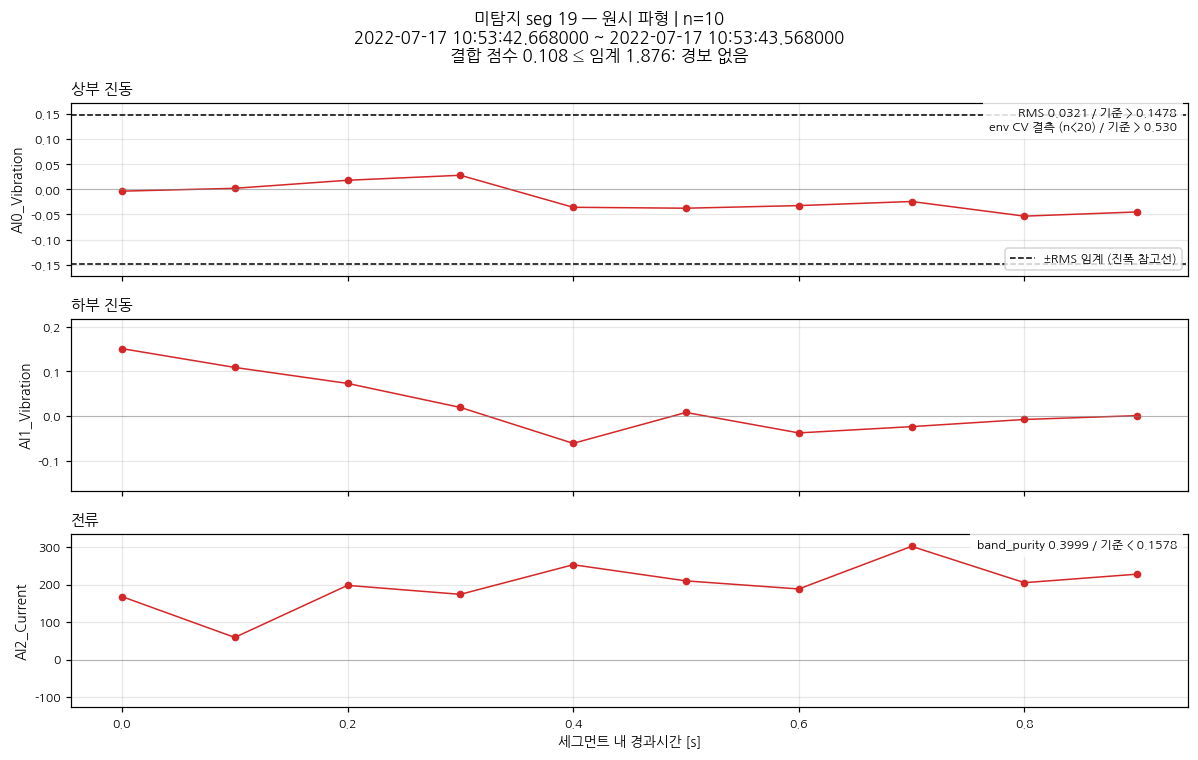

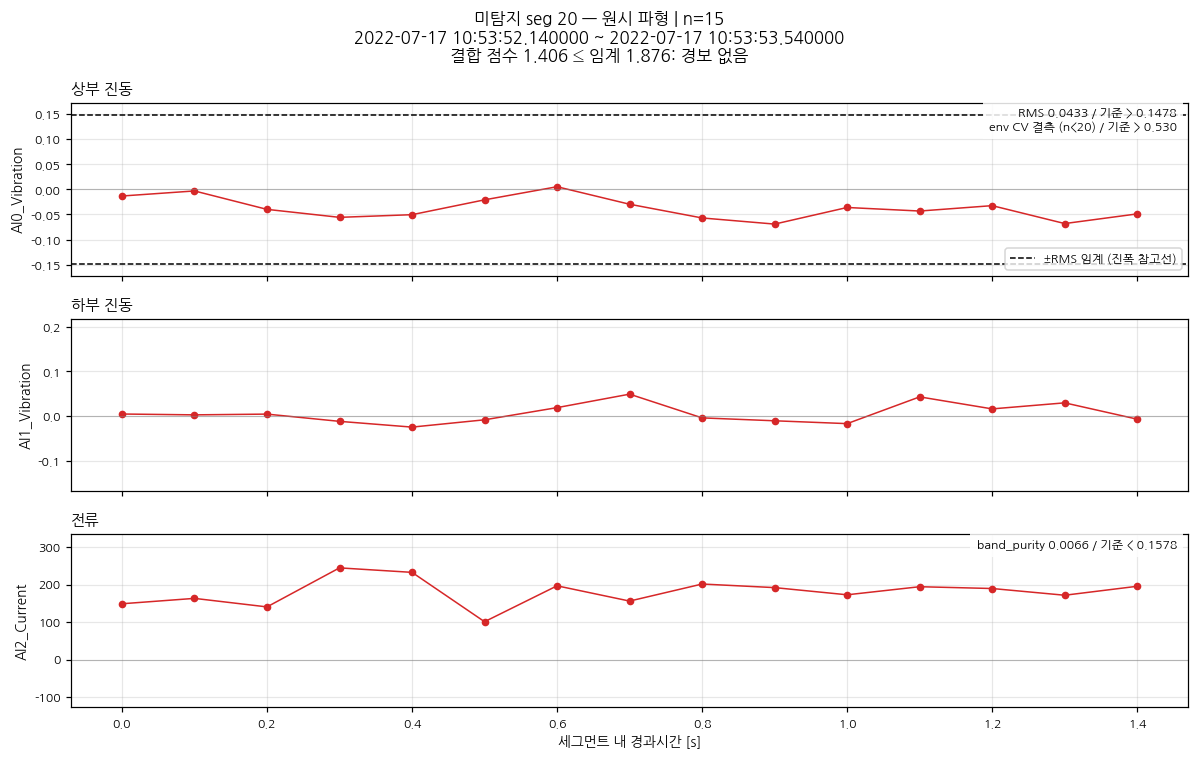

In [7]:
raw_channels = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
raw_names = ["상부 진동", "하부 진동", "전류"]
raw_ids = Fo.loc[Fo.score <= thr_combo, "seg_id"].tolist()
raw_segments = {sid: SEG["outlier"].loc[SEG["outlier"].seg_id == sid].copy()
                for sid in raw_ids}
rms_threshold = train.ai0_rms.max()
purity_threshold = train.purity.min()
env_threshold = train.env_cv.max()
raw_limits = {}
for channel in raw_channels:
    values = pd.concat([g[channel] for g in raw_segments.values()])
    lo, hi = values.min(), values.max()
    if channel == "AI0_Vibration":
        lo, hi = min(lo, -rms_threshold), max(hi, rms_threshold)
    pad = max((hi - lo) * .08, .001)
    raw_limits[channel] = (lo - pad, hi + pad)

for sid, g in raw_segments.items():
    features = Fo.loc[Fo.seg_id == sid].iloc[0]
    elapsed = (g.TimeStamp - g.TimeStamp.iloc[0]).dt.total_seconds()
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    for ax, channel, name in zip(axes, raw_channels, raw_names):
        ax.plot(elapsed, g[channel], "o-", color=COLOR["outlier"], lw=1, ms=4)
        ax.axhline(0, color="gray", lw=.7, alpha=.5)
        ax.set_ylim(*raw_limits[channel])
        ax.set_ylabel(channel)
        ax.set_title(name, loc="left")
    for sign in [-1, 1]:
        axes[0].axhline(sign * rms_threshold, color="black", ls="--", lw=1,
                        label="±RMS 임계 (진폭 참고선)" if sign == 1 else None)
    env_value = f"{features.env_cv:.3f}" if pd.notna(features.env_cv) else "결측 (n<20)"
    axes[0].text(.99, .97,
                 f"RMS {features.ai0_rms:.4f} / 기준 > {rms_threshold:.4f}\n"
                 f"env CV {env_value} / 기준 > {env_threshold:.3f}",
                 transform=axes[0].transAxes, ha="right", va="top", fontsize=8,
                 bbox=dict(facecolor="white", alpha=.85, edgecolor="none"))
    axes[0].legend(loc="lower right", fontsize=8)
    axes[2].text(.99, .97,
                 f"band_purity {features.purity:.4f} / 기준 < {purity_threshold:.4f}",
                 transform=axes[2].transAxes, ha="right", va="top", fontsize=8,
                 bbox=dict(facecolor="white", alpha=.85, edgecolor="none"))
    axes[-1].set_xlabel("세그먼트 내 경과시간 [s]")
    fig.suptitle(f"미탐지 seg {sid} — 원시 파형 | n={len(g)}\n"
                 f"{g.TimeStamp.iloc[0]} ~ {g.TimeStamp.iloc[-1]}\n"
                 f"결합 점수 {features.score:.3f} ≤ 임계 {thr_combo:.3f}: 경보 없음", fontsize=11)
    plt.tight_layout(); plt.show()


## 4. 정리 및 04로 넘길 것

### 확인된 사실

| # | 항목 | 결과 |
|---|---|---|
| 1 | 정상 내부 오경보율(최우선) | **0~0.6%** (V자 딥 구간 포함 test셋 기준). 우려했던 드리프트발 오경보는 기우였음 |
| 2 | 결합 점수 성능 | test 오경보 0%, outlier 14/17 탐지, AUC 0.979 |
| 3 | 미탐지 3개 재확인 | seg 3·19·20 — 3가지 독립 방법(01 임계/02 tier/03 결합점수) 전부 동일 → 원리적 하한으로 확정 |

### 04(모델링)로 넘길 설계 결정

1. **결합 점수(rms + purity + env_cv, z-score 평균)를 기본 이상도 점수로 채택.** 단순
   평균이라 튜닝 여지가 있지만(가중치, 로버스트 통계 등), 이미 test 오경보 0%·탐지
   14/17로 베이스라인은 확실하다.
2. **"N 중 M회" 지속성 규칙은 04에서 별도 검증이 필요하다.** 이 노트북에서는 시도하지
   않았다 — outlier가 21개 원본 세그먼트·2.8분뿐이라, 지속성 윈도우(N, M)를 이 데이터
   안에서 튜닝하면 그 자체로 과적합될 위험이 크다. 04에서는 04-1(부트스트랩/교차검증)과
   함께 다뤄야 한다.
3. **베이스라인은 rolling/EWMA로 전환할지 재검토.** 이번 정적(앞70%/뒤30%) 분할에서
   이미 오경보 0%가 나왔기 때문에, 01·02에서 예상했던 것만큼 rolling 기준선이 필수는
   아닐 수 있다. 다만 이건 "77분짜리 데이터 안에서"의 결론이라, 더 긴 운전 기간에서도
   유지되는지는 실제 운영 데이터로 확인이 필요하다.
4. **미탐지 3개는 모델 성능 한계가 아니라 하한으로 보고한다.** 04의 평가 프로토콜에서
   "17개 중 14개(82%) + 이 3개는 신호 자체가 정상 범위 안이라 원리적 미탐지"로 명시.
5. **평가 신뢰구간.** outlier가 17개뿐이라 82%(14/17)라는 점추정은 불안정하다.
   부트스트랩으로 신뢰구간을 붙여 보고한다.